# Preprocessing

So far, I cleaned and combined the tract-level data, finished the EDA, reviewed feature relationships, documented what to keep or drop, and saved the final EDA dataset. I also decided to keep the main modeling work countywide, use safety as an SDPD-only screening layer, and use `estimated_median_gross_rent` as the regression target.

In this notebook, I’ll:

- load the final EDA dataset
- create separate feature sets for regression and clustering
- remove identifiers and context-only fields from the modeling inputs
- handle the remaining missing income values
- transform the highly skewed density features
- review multicollinearity and remove redundant features where needed
- scale numeric features for clustering
- split the regression data into train and test sets
- save the cleaned modeling-ready datasets for the next notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data_path = Path('../data/processed/master_residential_tract_features_final_eda.csv')
df = pd.read_csv(data_path)

df.shape

(727, 77)

In [3]:
df[['tract_id', 'tract_name', 'estimated_median_gross_rent']].head()

,tract_id,tract_name,estimated_median_gross_rent
0,6073000100,Census Tract 1; San Diego County; California,2941.5
1,6073000201,Census Tract 2.01; San Diego County; California,2407.0
2,6073000202,Census Tract 2.02; San Diego County; California,1992.0
3,6073000301,Census Tract 3.01; San Diego County; California,1945.0
4,6073000302,Census Tract 3.02; San Diego County; California,2412.0


In [5]:
target = 'estimated_median_gross_rent'

features = [
    'walkability_index', 'public_transit_commute_rate', 'no_vehicle_rate', 'work_from_home_rate',
    'climate_loss_risk_score', 'heat_risk_score', 'flood_risk_score', 'wildfire_risk_score',
    'social_vulnerability_score', 'school_academic_score', 'median_household_income', 'poverty_rate',
    'unemployment_rate', 'renter_rate', 'vacancy_rate', 'population_under_18_rate',
    'avg_household_size', 'median_age', 'transit_stop_density', 'school_density']

df[features + [target]].isna().sum().sort_values(ascending=False).head(10)

median_household_income        8
public_transit_commute_rate    0
no_vehicle_rate                0
work_from_home_rate            0
walkability_index              0
climate_loss_risk_score        0
heat_risk_score                0
wildfire_risk_score            0
flood_risk_score               0
social_vulnerability_score     0
dtype: int64

## Imputing missing values

I could have addressed this in data wrangling or EDA, but I wasn't sure if it the missing values would have a substantial effect if they were left as is. Ultimately I decided that I could address them easily enough, and impute a median based on nearby tracts (83.11, 83.12, 83.13, etc). If for some reason a null value didn't have an associated median, it would just get the county median imputed. 

In [9]:
# filling missing income with the median from related tract numbers

base_tract = df['tract_name'].str.extract(r'Tract (\d+)')[0] # searching each string in 'tract_name' for digits +1, then saves the first captured group ('83')
group_median = df.groupby(base_tract)['median_household_income'].transform('median') # groups the rows 

df['median_household_income'] = (  # calculates the median for each base tract, uses countywide median if there's no base tract
    df['median_household_income'] 
    .fillna(group_median)
    .fillna(df['median_household_income'].median()))

df['median_household_income'].isna().sum()

np.int64(0)

## Transforming skewed data

During EDA I found that transit stop and school density were skewed because a few tracts really dominate in those areas. Doing a log transform helps balance it out, even though there are still plenty of tracts with 0 in both school and transit stop density. 

In [10]:
df[['transit_stop_density', 'school_density']].skew().round(2)

transit_stop_density    4.39
school_density          3.05
dtype: float64

In [11]:
# reducing extreme density values before modeling
df['transit_stop_density_log'] = np.log1p(df['transit_stop_density'])
df['school_density_log'] = np.log1p(df['school_density'])

df[['transit_stop_density_log', 'school_density_log']].skew().round(2)

transit_stop_density_log   -0.34
school_density_log          0.71
dtype: float64

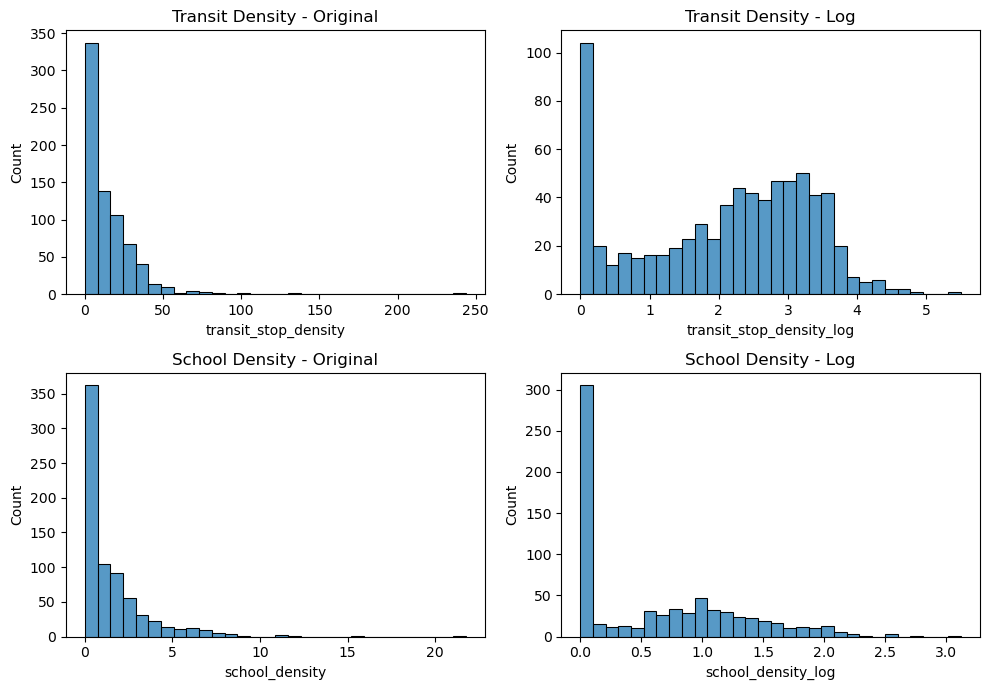

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

sns.histplot(df['transit_stop_density'], bins=30, ax=axes[0, 0])
sns.histplot(df['transit_stop_density_log'], bins=30, ax=axes[0, 1])
sns.histplot(df['school_density'], bins=30, ax=axes[1, 0])
sns.histplot(df['school_density_log'], bins=30, ax=axes[1, 1])

axes[0, 0].set_title('Transit Density - Original')
axes[0, 1].set_title('Transit Density - Log')
axes[1, 0].set_title('School Density - Original')
axes[1, 1].set_title('School Density - Log')

plt.tight_layout()
plt.show()

In [16]:
features = [
    'walkability_index', 'public_transit_commute_rate', 'no_vehicle_rate', 'work_from_home_rate',
    'climate_loss_risk_score', 'heat_risk_score', 'flood_risk_score', 'wildfire_risk_score',
    'social_vulnerability_score', 'school_academic_score', 'median_household_income', 'poverty_rate',
    'unemployment_rate', 'renter_rate', 'vacancy_rate', 'population_under_18_rate',
    'avg_household_size', 'median_age', 'transit_stop_density_log', 'school_density_log']

corr = df[features].corr().abs() # calculating Pearson coefficient from 'features', giving the absolute value for each.
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().sort_values(ascending=False) # keeping each correlation pair once, then sorting them

The strongest relationships were between walkability and transit density, climate loss risk and flood risk (which are related, but still give different information, and population under 18/avg household size (also different information, but still related). I think it's OK to move forward with all of these features.

In [17]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((581, 20), (146, 20))

## Scaling
Since all the features are different types of numeric values (ie: annual income $140,000 vs school score of 3), I need to adjust so they work for modeling.

In [18]:
# scaling features so different units are on a similar range
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((581, 20), (146, 20))

In [20]:
# putting the scaled values back into dataframes so we keep the feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

X_train_scaled.head().T

,136,286,6,657,587
walkability_index,1.353940,0.406721,0.401510,0.159932,-0.577403
public_transit_commute_rate,-0.508924,0.975066,0.098163,-0.677559,0.199344
no_vehicle_rate,0.052332,1.166374,-0.136198,-0.170477,-0.341868
work_from_home_rate,0.610989,-0.920624,1.083709,-0.844989,-1.374436
climate_loss_risk_score,0.203214,0.037879,-0.946229,0.649158,-0.191411
heat_risk_score,-1.243055,-0.158053,-1.131361,0.866806,2.047004
flood_risk_score,-1.318241,0.424241,-1.659642,1.222290,-0.025571
wildfire_risk_score,-1.119506,0.194224,0.743872,1.184740,1.259157
social_vulnerability_score,-1.100549,0.980260,-0.331717,0.031157,1.180939
school_academic_score,0.361577,-1.093917,0.361577,-1.093917,0.361577


In [21]:
# scaling all tracts for clustering
cluster_scaler = StandardScaler()
X_cluster = pd.DataFrame(
    cluster_scaler.fit_transform(df[features]),
    columns=features,
    index=df.index)

X_cluster.shape

(727, 20)

In [22]:
# saving the prepared regression and clustering datasets
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv')
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv')
y_train.to_csv('../data/processed/y_train.csv')
y_test.to_csv('../data/processed/y_test.csv')
X_cluster.to_csv('../data/processed/X_cluster_scaled.csv')

### Categorical features

The final modeling feature set only includes numeric variables, so I don't need any dummy or one-hot encoded features. Categorical fields like district names context during EDA, but not for modeling. I think for another version I might do dummy features to identify the actual school districts by number, but it didn't feel imperative for this version. 

### Preprocessing summary

The final modeling features are now cleaned and ready. I filled the last null income values, log-transformed the transit and school density features, checked for feature overlap, split the regression data into train and test sets, and scaled the inputs.
I made a separate scaled dataset with all 727 tracts for clustering.